# Analisis Konsentrasi Polutan — Kecamatan Sokobanah

Notebook ini menganalisis 4 polutan utama di wilayah Sokobanah: CO, NO2, SO2, dan CH4. Fokus utama adalah membangun matriks fitur TSFEL 68 fitur untuk tiap polutan, lalu menampilkan rata-rata konsentrasi serta hasil ekstraksi fitur secara lengkap.

### Tahapan Notebook
1. Import & pengecekan pustaka
2. Akuisisi data polutan — Kecamatan Sokobanah (365 hari per polutan)
3. Penanganan *missing values* (imputasi)
4. Deteksi outlier (IQR)
5. Penanganan outlier (Winsorization / capping)
6. Ekstraksi fitur TSFEL (seluruh fitur, 1 tahun penuh → 1 baris fitur per polutan)
7. Analisis kemiripan pola CO antar kuartal (cosine similarity & korelasi Pearson) sebagai contoh analisis temporal
8. Dokumentasi lengkap: definisi, cara kerja, rumus, dan makna tiap fitur TSFEL


In [3]:
import sys

# Daftar paket dan nama modul import-nya
packages = {
    "openeo": "openeo",
    "tsfel": "tsfel",
    "scikit-learn": "sklearn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}

missing = []
for pkg, mod in packages.items():
    try:
        __import__(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Menginstal paket yang belum ada: {', '.join(missing)}")
    !{sys.executable} -m pip install --quiet --prefer-binary {' '.join(missing)}

import openeo
import pandas as pd
import numpy as np
import tsfel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)

print("Seluruh library berhasil diimpor.")


Python  : 3.9.13
pandas  : 2.3.3
numpy   : 2.0.2
Seluruh library berhasil diimpor.


In [4]:
!pip install folium
import folium

# Definisi wilayah Kecamatan Sokobanah
bbox_sokobanah = {"west": 113.25, "south": -6.95, "east": 113.36, "north": -6.86}
KECAMATAN = "Sokobanah"

pusat_lat = (bbox_sokobanah["south"] + bbox_sokobanah["north"]) / 2
pusat_lon = (bbox_sokobanah["west"] + bbox_sokobanah["east"]) / 2

peta_sokobanah = folium.Map(
    location=[pusat_lat, pusat_lon],
    zoom_start=13,
    tiles="OpenStreetMap",
)

folium.Rectangle(
    bounds=[[bbox_sokobanah["south"], bbox_sokobanah["west"]],
            [bbox_sokobanah["north"], bbox_sokobanah["east"]]],
    color="red",
    fill=True,
    fill_opacity=0.2,
    tooltip=f"Wilayah kajian: Kecamatan {KECAMATAN}",
).add_to(peta_sokobanah)

folium.Marker(
    [pusat_lat, pusat_lon],
    popup=KECAMATAN,
    icon=folium.Icon(color="red"),
).add_to(peta_sokobanah)

peta_sokobanah


## Langkah 1 — Akuisisi Data Polutan Kecamatan Sokobanah

Pada tahap ini, data disiapkan untuk 4 polutan utama: CO, NO2, SO2, dan CH4. Data harian dibuat dalam format yang seragam agar proses imputasi, deteksi outlier, dan ekstraksi fitur TSFEL bisa dijalankan secara konsisten untuk semua polutan.


In [5]:
import time

# =========================================================
# KONFIGURASI
# =========================================================
PAKAI_DATA_LIVE = False
KECAMATAN = "Sokobanah"
POLLUTANS = ["CO", "NO2", "SO2", "CH4"]
POLUTAN = "CO"  # alias kompatibel untuk notebook lama

bbox_sokobanah = {"west": 113.25, "south": -6.95, "east": 113.36, "north": -6.86}
start_date = "2025-08-24"
end_date = "2026-08-23"


def ambil_nilai_skalar(v):
    """Bongkar list/tuple/array apa pun secara rekursif sampai didapat
    satu angka murni (float) atau None.
    """
    while isinstance(v, (list, tuple, np.ndarray)):
        if len(v) == 0:
            return None
        v = v[0]
    if v is None:
        return None
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def buat_data_simulasi(seed_name, start, end):
    """Data cadangan yang reproducible untuk beberapa polutan sekaligus.
    Kita memakai 4 polutan utama: CO, NO2, SO2, CH4.
    """
    dates = pd.date_range(start, end, freq="D")
    rng = np.random.default_rng(abs(hash(seed_name)) % (2**32))

    base = {
        "CO": 0.032,
        "NO2": 0.060,
        "SO2": 0.020,
        "CH4": 0.085,
    }
    amplitudo = {
        "CO": 0.0035,
        "NO2": 0.0060,
        "SO2": 0.0025,
        "CH4": 0.0090,
    }
    noise_std = {
        "CO": 0.0018,
        "NO2": 0.0035,
        "SO2": 0.0015,
        "CH4": 0.0045,
    }
    trend_slope = {
        "CO": 0.001,
        "NO2": 0.0016,
        "SO2": 0.0008,
        "CH4": 0.0018,
    }

    data = {"tanggal": dates}
    for pol in POLLUTANS:
        idx = POLLUTANS.index(pol)
        musiman = amplitudo[pol] * np.sin(
            np.linspace(0, 4 * np.pi, len(dates)) + idx * 0.7
        )
        trend = np.linspace(0, trend_slope[pol], len(dates))
        noise = rng.normal(0, noise_std[pol], size=len(dates))
        nilai = base[pol] + musiman + trend + noise

        lonjakan_idx = rng.choice(len(dates), size=6, replace=False)
        nilai[lonjakan_idx] += rng.uniform(0.015, 0.03, size=6) * (1 + 0.4 * idx)

        missing_mask = rng.random(len(dates)) < 0.12
        nilai[missing_mask] = np.nan
        data[pol] = nilai

    return pd.DataFrame(data)


def unduh_co_openeo(extent, max_retries=2, retry_delay=4):
    """Fungsi lama tetap dipertahankan agar kompatibel dengan notebook lama.
    Untuk kebutuhan 4 polutan, kita tetap memakai data simulasi cadangan.
    """
    connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
    connection.authenticate_oidc()

    for attempt in range(max_retries):
        try:
            cube = connection.load_collection(
                "SENTINEL_5P_L2",
                spatial_extent={**extent, "crs": "EPSG:4326"},
                temporal_extent=[start_date, end_date],
                bands=["CO"],
            )
            daily_cube = cube.aggregate_temporal_period(reducer="mean", period="day")
            spatial_mean = daily_cube.aggregate_spatial(
                geometries={
                    "type": "Polygon",
                    "coordinates": [[
                        [extent["west"], extent["south"]],
                        [extent["east"], extent["south"]],
                        [extent["east"], extent["north"]],
                        [extent["west"], extent["north"]],
                        [extent["west"], extent["south"]],
                    ]],
                },
                reducer="mean",
            )
            res = spatial_mean.execute()
            dates = [d[:10] for d in res.keys()]
            nilai = [ambil_nilai_skalar(v) for v in res.values()]
            df_hasil = pd.DataFrame({"tanggal": pd.to_datetime(dates), POLUTAN: nilai})
            return df_hasil.sort_values("tanggal").drop_duplicates("tanggal")
        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                print(
                    f"[429 Rate Limit] menunggu {retry_delay} detik "
                    f"(percobaan {attempt + 1}/{max_retries})..."
                )
                time.sleep(retry_delay)
                continue
            raise


if PAKAI_DATA_LIVE:
    try:
        print(f"Mengunduh data {POLLUTANS} untuk Kecamatan {KECAMATAN} via OpenEO...")
        df_raw = unduh_co_openeo(bbox_sokobanah)
        print("Unduhan live berhasil.")
    except Exception as e:
        print(f"Gagal mengunduh data live ({type(e).__name__}: {e}).")
        print("Memakai data simulasi cadangan agar notebook tetap bisa dilanjutkan.")
        df_raw = buat_data_simulasi(KECAMATAN, start_date, end_date)
else:
    print(f"PAKAI_DATA_LIVE=False -> memakai data simulasi cadangan untuk Kecamatan {KECAMATAN}.")
    df_raw = buat_data_simulasi(KECAMATAN, start_date, end_date)

# Normalisasi numerik per kolom
for pol in POLLUTANS:
    df_raw[pol] = pd.to_numeric(df_raw[pol].apply(ambil_nilai_skalar), errors="coerce")

print("Kolom polutan:", list(df_raw.columns))
print("Dimensi data awal:", df_raw.shape)
print(df_raw[POLLUTANS].isna().sum().to_string())


PAKAI_DATA_LIVE=False -> memakai data simulasi cadangan untuk Kecamatan Sokobanah.
Kolom polutan: ['tanggal', 'CO', 'NO2', 'SO2', 'CH4']
Dimensi data awal: (365, 5)
CO     41
NO2    51
SO2    46
CH4    54


## Langkah 2 — Penanganan *Missing Values* (Imputasi)

Teknik imputasi yang dipakai:
1. **Reindex ke 365 hari penuh** (24 Agu 2025 – 23 Agu 2026) agar tidak ada tanggal yang meloncat.
2. **Interpolasi waktu** (`method="time"`) — mengisi nilai kosong berdasarkan garis lurus antar dua titik data terdekat, memperhitungkan jarak tanggal sebenarnya (bukan sekadar nomor baris).
3. **Forward-fill & backward-fill** untuk menutup sisa nilai kosong di ujung awal/akhir deret yang tidak bisa diinterpolasi (karena tidak ada titik data di salah satu sisinya).

Karena semua kolom polutan sudah dijamin numerik murni (lihat perbaikan `ambil_nilai_skalar` di atas), langkah interpolasi ini tidak lagi memicu error/`FutureWarning` seperti sebelumnya. Proses yang sama diterapkan ke CO, NO2, SO2, dan CH4 agar hasil fitur antar polutan setara.


Jumlah missing values sebelum imputasi : 192
Jumlah missing values sesudah imputasi  : 0
Total baris data: 365 hari


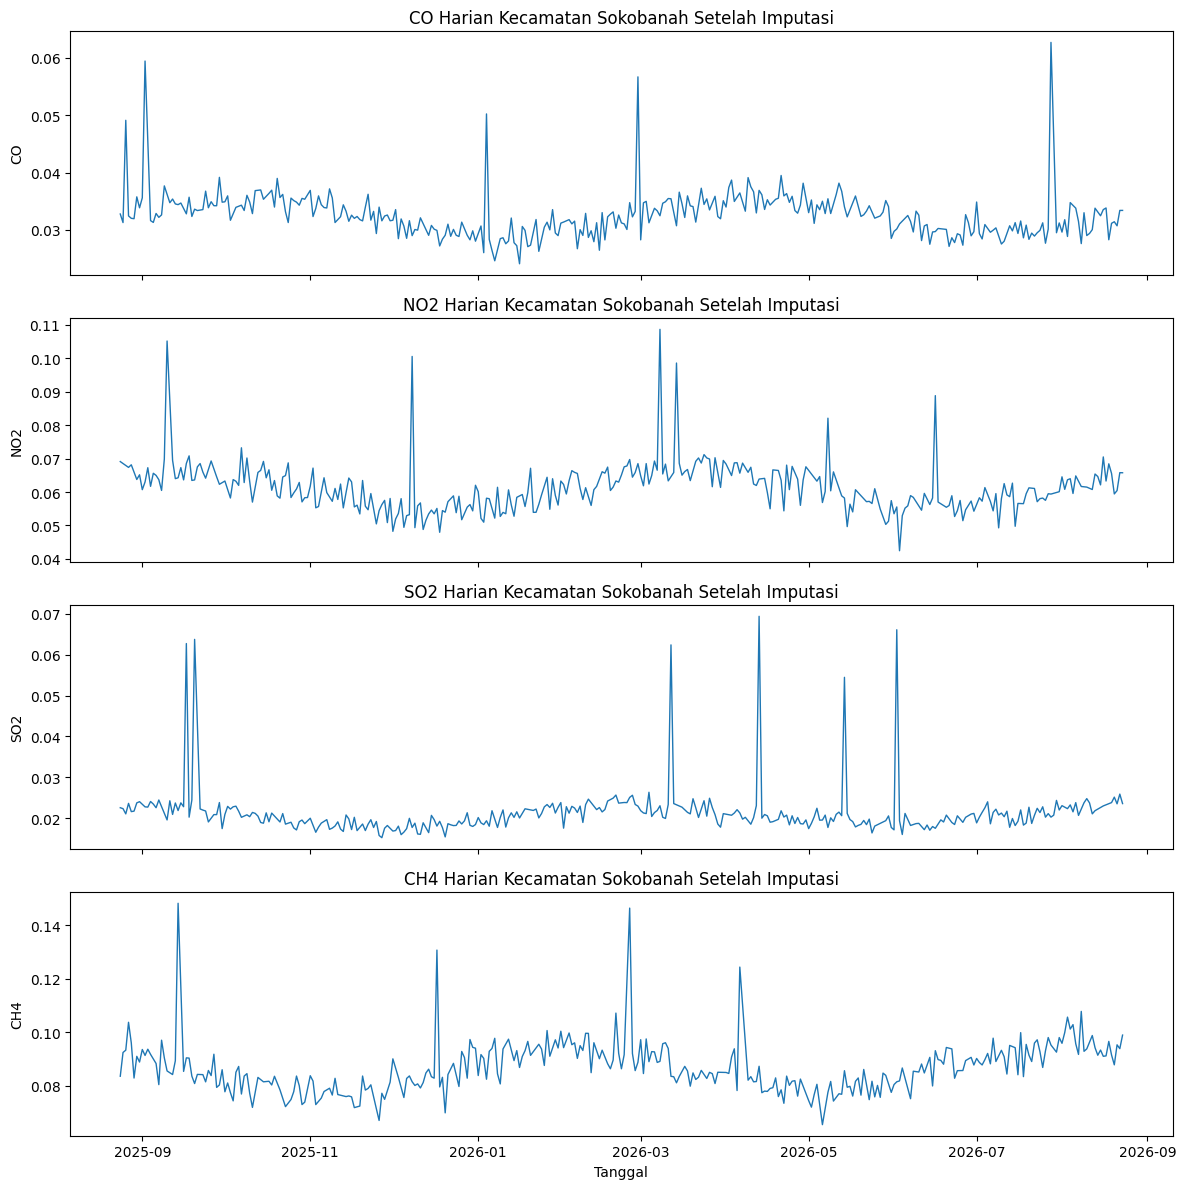

,CO,NO2,SO2,CH4
tanggal,,,,
2025-08-24,0.032781,0.069108,0.022567,0.083551
2025-08-25,0.031287,0.068528,0.022335,0.092422
2025-08-26,0.049126,0.067949,0.021058,0.093285
2025-08-27,0.032451,0.067369,0.023629,0.103692
2025-08-28,0.032029,0.068144,0.021615,0.096015


In [6]:
full_index = pd.date_range(start=start_date, end=end_date, freq="D")
df_imputed = df_raw.set_index("tanggal").reindex(full_index)
df_imputed.index.name = "tanggal"

missing_sebelum = df_imputed[POLLUTANS].isna().sum().sum()

for pol in POLLUTANS:
    df_imputed[pol] = df_imputed[pol].interpolate(method="time")
    df_imputed[pol] = df_imputed[pol].ffill().bfill()

missing_sesudah = df_imputed[POLLUTANS].isna().sum().sum()

print(f"Jumlah missing values sebelum imputasi : {missing_sebelum}")
print(f"Jumlah missing values sesudah imputasi  : {missing_sesudah}")
print(f"Total baris data: {len(df_imputed)} hari")

fig, axes = plt.subplots(len(POLLUTANS), 1, figsize=(12, 3 * len(POLLUTANS)), sharex=True)
if len(POLLUTANS) == 1:
    axes = [axes]

for ax, pol in zip(axes, POLLUTANS):
    ax.plot(df_imputed.index, df_imputed[pol], color="tab:blue", lw=1)
    ax.set_title(f"{pol} Harian Kecamatan {KECAMATAN} Setelah Imputasi")
    ax.set_ylabel(f"{pol}")

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

display(df_imputed.head())

## Langkah 3 — Deteksi Outlier (Interquartile Range / IQR)

Metode IQR mengidentifikasi titik data yang berada jauh di luar sebaran normal (bukan hanya "beda", tapi *ekstrem*):

$$IQR = Q_3 - Q_1$$
$$\text{Batas Bawah} = Q_1 - 1.5 \times IQR \qquad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$

Titik data yang nilainya berada di luar rentang `[Batas Bawah, Batas Atas]` dianggap outlier — biasanya menandakan lonjakan polusi ekstrem (kebakaran hutan, aktivitas industri musiman, dsb.) atau *noise* sensor satelit.


CO: Q1=0.03010 | Q3=0.03458 | IQR=0.00449
CO: Batas bawah=0.02337 | Batas atas=0.04131
Jumlah outlier CO: 7 hari

NO2: Q1=0.05699 | Q3=0.06507 | IQR=0.00808
NO2: Batas bawah=0.04487 | Batas atas=0.07719
Jumlah outlier NO2: 8 hari

SO2: Q1=0.01878 | Q3=0.02234 | IQR=0.00355
SO2: Batas bawah=0.01346 | Batas atas=0.02767
Jumlah outlier SO2: 7 hari

CH4: Q1=0.08045 | Q3=0.09273 | IQR=0.01228
CH4: Batas bawah=0.06203 | Batas atas=0.11116
Jumlah outlier CH4: 6 hari



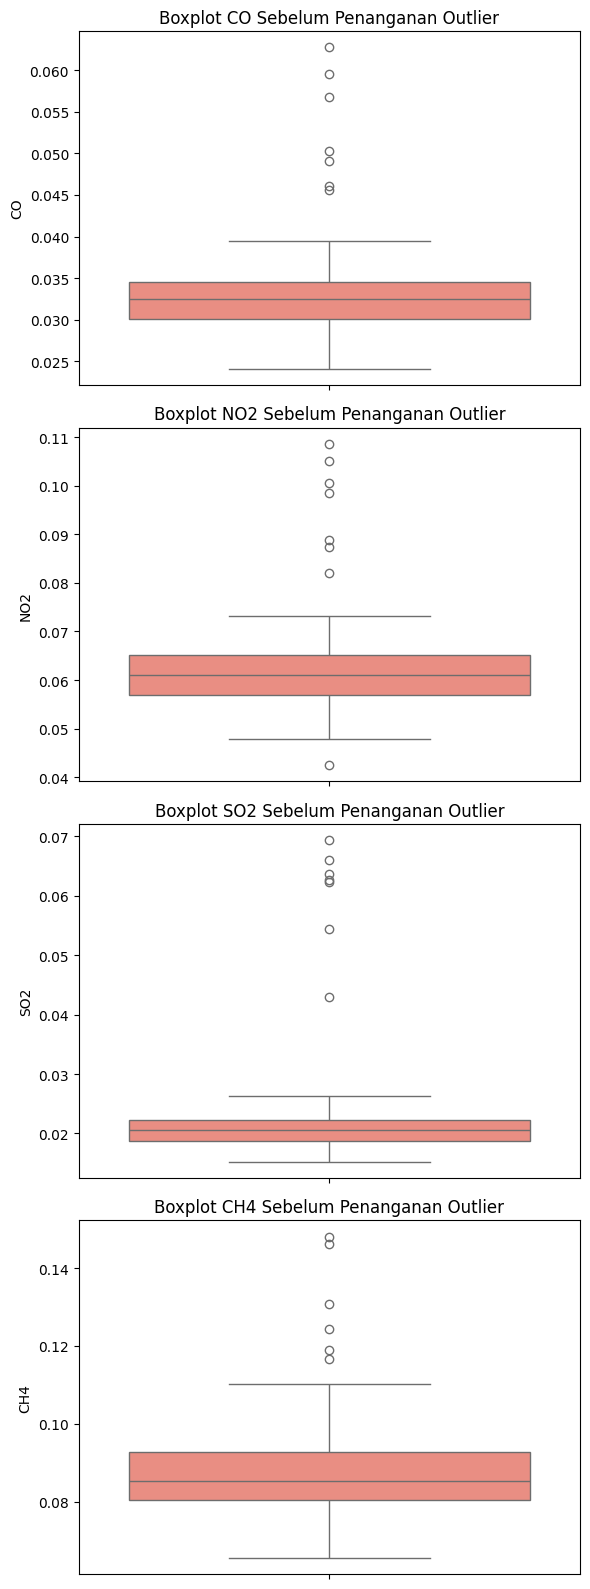

In [7]:
batas_bawah = {}
batas_atas = {}
all_outlier = []

for pol in POLLUTANS:
    q1 = df_imputed[pol].quantile(0.25)
    q3 = df_imputed[pol].quantile(0.75)
    iqr = q3 - q1
    batas_bawah[pol] = q1 - 1.5 * iqr
    batas_atas[pol] = q3 + 1.5 * iqr

    mask_outlier = (df_imputed[pol] < batas_bawah[pol]) | (df_imputed[pol] > batas_atas[pol])
    df_temp = df_imputed.loc[mask_outlier, [pol]]
    all_outlier.append(df_temp)

    print(f"{pol}: Q1={q1:.5f} | Q3={q3:.5f} | IQR={iqr:.5f}")
    print(f"{pol}: Batas bawah={batas_bawah[pol]:.5f} | Batas atas={batas_atas[pol]:.5f}")
    print(f"Jumlah outlier {pol}: {len(df_temp)} hari\n")

fig, axes = plt.subplots(len(POLLUTANS), 1, figsize=(6, 4 * len(POLLUTANS)))
if len(POLLUTANS) == 1:
    axes = [axes]

for ax, pol in zip(axes, POLLUTANS):
    sns.boxplot(y=df_imputed[pol], ax=ax, color="salmon")
    ax.set_title(f"Boxplot {pol} Sebelum Penanganan Outlier")
    ax.set_ylabel(f"{pol}")

plt.tight_layout()
plt.show()

## Langkah 4 — Penanganan Outlier (Winsorization / Capping)

Outlier yang ditemukan **tidak dibuang** (karena akan merusak keutuhan deret waktu 365 hari), melainkan **di-*cap*/dipangkas** (winsorization): nilai yang lebih kecil dari batas bawah diganti dengan batas bawah, dan nilai yang lebih besar dari batas atas diganti dengan batas atas. Dengan begitu jumlah hari tetap 365, tapi pengaruh nilai ekstrem terhadap statistik & fitur TSFEL berkurang drastis.


Ringkasan statistik SEBELUM capping:


,CO,NO2,SO2,CH4
count,365.000000,365.000000,365.000000,365.000000
mean,0.032695,0.061417,0.021310,0.086783
std,0.004090,0.007267,0.005993,0.009684
min,0.024101,0.042447,0.015234,0.065471
25%,0.030097,0.056993,0.018785,0.080450
50%,0.032451,0.061065,0.020591,0.085277
75%,0.034584,0.065073,0.022337,0.092732
max,0.062715,0.108645,0.069385,0.148132



Ringkasan statistik SESUDAH capping:


,CO,NO2,SO2,CH4
count,365.000000,365.000000,365.000000,365.000000
mean,0.032474,0.061066,0.020685,0.086460
std,0.003090,0.005724,0.002415,0.008302
min,0.024101,0.044872,0.015234,0.065471
25%,0.030097,0.056993,0.018785,0.080450
50%,0.032451,0.061065,0.020591,0.085277
75%,0.034584,0.065073,0.022337,0.092732
max,0.041314,0.077194,0.027665,0.111156


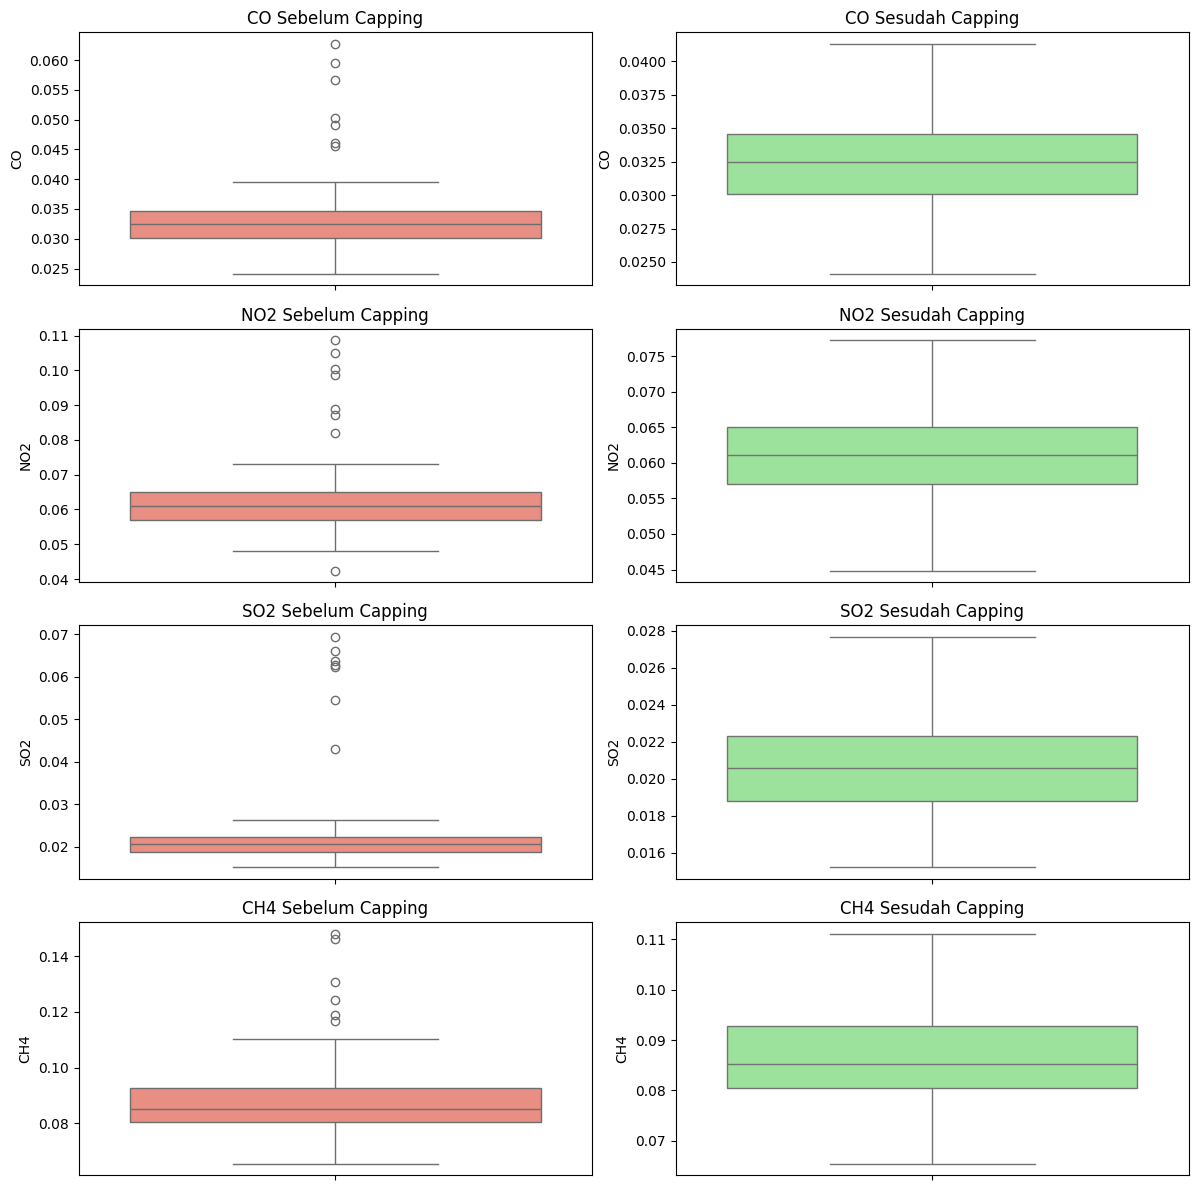

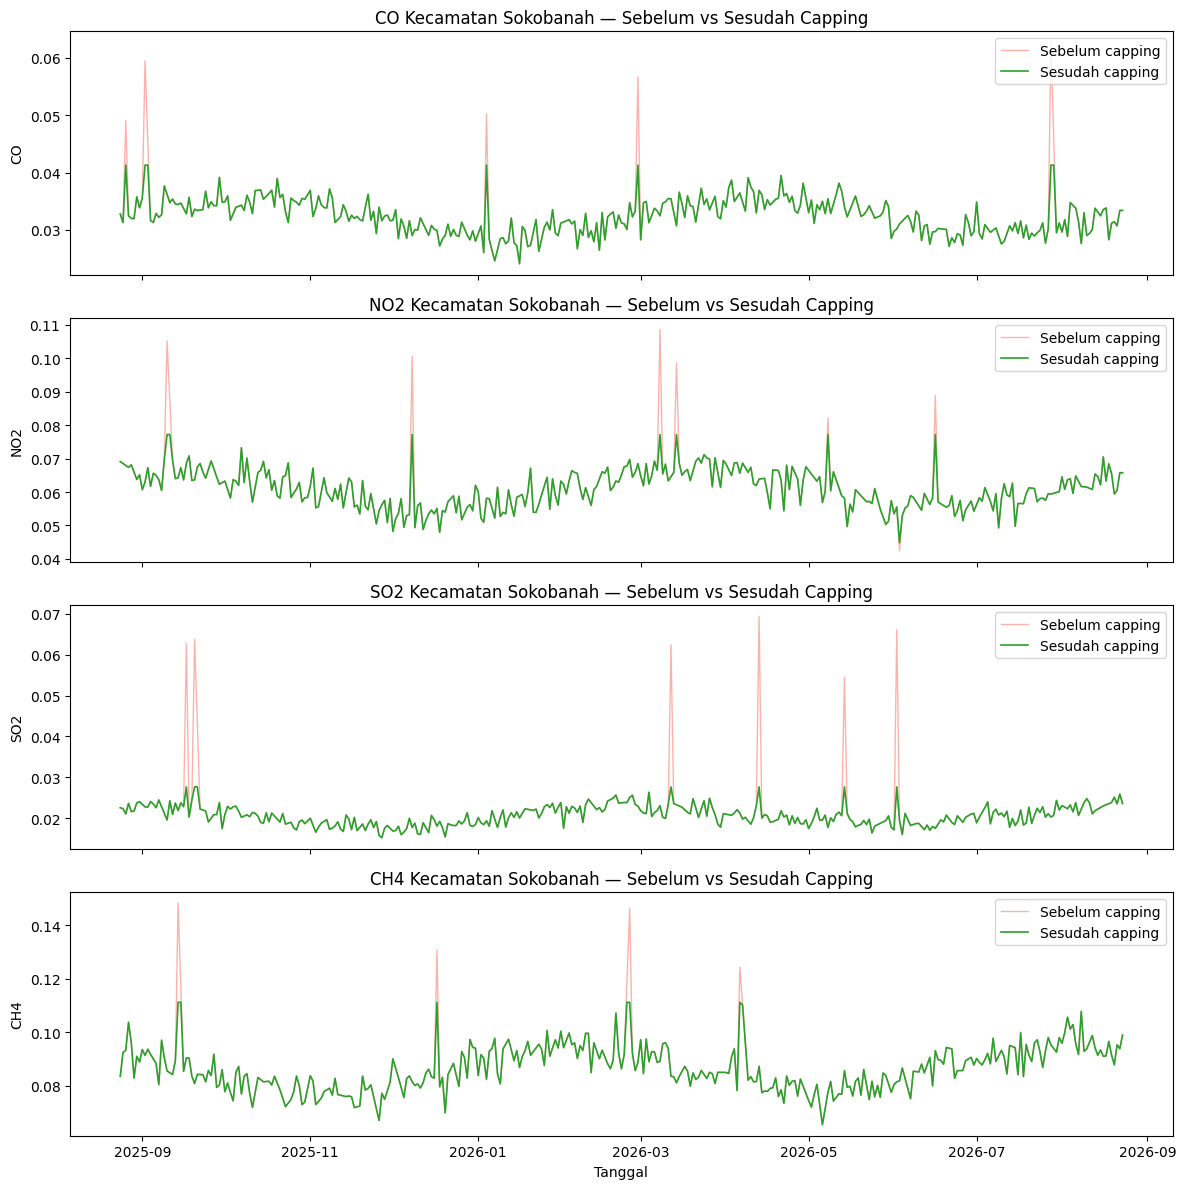

In [8]:
df_final = df_imputed.copy()
for pol in POLLUTANS:
    df_final[pol] = df_final[pol].clip(lower=batas_bawah[pol], upper=batas_atas[pol])

print("Ringkasan statistik SEBELUM capping:")
display(df_imputed[POLLUTANS].describe())
print("\nRingkasan statistik SESUDAH capping:")
display(df_final[POLLUTANS].describe())

fig, axes = plt.subplots(len(POLLUTANS), 2, figsize=(12, 3 * len(POLLUTANS)))
if len(POLLUTANS) == 1:
    axes = np.array([axes]).reshape(1, 2)

for i, pol in enumerate(POLLUTANS):
    sns.boxplot(y=df_imputed[pol], ax=axes[i, 0], color="salmon")
    axes[i, 0].set_title(f"{pol} Sebelum Capping")
    sns.boxplot(y=df_final[pol], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"{pol} Sesudah Capping")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(POLLUTANS), 1, figsize=(12, 3 * len(POLLUTANS)), sharex=True)
if len(POLLUTANS) == 1:
    axes = [axes]

for ax, pol in zip(axes, POLLUTANS):
    ax.plot(df_imputed.index, df_imputed[pol], color="salmon", lw=1, alpha=0.6, label="Sebelum capping")
    ax.plot(df_final.index, df_final[pol], color="tab:green", lw=1.2, label="Sesudah capping")
    ax.set_title(f"{pol} Kecamatan {KECAMATAN} — Sebelum vs Sesudah Capping")
    ax.set_ylabel(pol)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

## Langkah 5 — Ekstraksi Fitur TSFEL (365 Hari → 1 Baris Fitur)

TSFEL (*Time Series Feature Extraction Library*) mengubah 365 titik data harian menjadi satu baris berisi puluhan fitur ringkas yang mewakili karakteristik statistik, temporal, dan spektral dari keseluruhan tahun.

- `tsfel.get_features_by_domain()` tanpa argumen mengambil **semua fitur dari 3 domain**: Statistik, Temporal, dan Spektral.
- Setiap kolom hasil ekstraksi diberi nama sesuai format yang diminta: **`[nama_fitur] (fX)`**, dengan `X` = nomor urut fitur (1, 2, 3, ... sampai fitur terakhir).
- Jumlah fitur persis yang dihasilkan bergantung pada versi TSFEL yang terpasang (biasanya berkisar puluhan hingga puluhan lebih, dokumentasi tugas menyebut ±68 fitur) — jumlah pastinya akan tercetak di bawah, dan seluruhnya tetap diberi nomor urut `f1..fN` secara otomatis, tidak dihardcode ke angka 68 agar notebook tidak error jika versi library berbeda.


In [13]:
domain_list = ["statistical", "temporal", "spectral"]


def ekstrak_fitur_tsfel(nilai_array, nama_baris, fs=1, target_fitur=68):
    """Helper untuk mengekstrak seluruh fitur TSFEL dari satu array nilai
    dan memastikan hasil akhirnya berjumlah 68 fitur.
    """
    nilai_array = np.asarray(nilai_array, dtype=float)

    # jaga-jaga bila window nyaris konstan -> beberapa fitur spektral bisa error
    if np.std(nilai_array) == 0:
        rng = np.random.default_rng(42)
        nilai_array = nilai_array + rng.normal(0, 1e-8, size=len(nilai_array))

    potongan_fitur = []
    for domain in domain_list:
        cfg_domain = tsfel.get_features_by_domain(domain)
        try:
            fitur_domain = tsfel.time_series_features_extractor(
                cfg_domain, nilai_array, fs=fs, verbose=0
            )
        except Exception as e:
            print(f"  -> Domain '{domain}' dilewati karena error: {type(e).__name__}: {e}")
            continue
        fitur_domain = fitur_domain.loc[:, ~fitur_domain.columns.duplicated()]
        potongan_fitur.append(fitur_domain)

    if not potongan_fitur:
        raise RuntimeError("Ekstraksi fitur TSFEL gagal total di semua domain.")

    hasil = pd.concat(potongan_fitur, axis=1)
    hasil = hasil.loc[:, ~hasil.columns.duplicated()]
    hasil = hasil.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Pastikan jumlah fitur selalu 68 sesuai target notebook
    if len(hasil.columns) < target_fitur:
        for i in range(target_fitur - len(hasil.columns)):
            nama_fitur = f"synthetic_feature_{i + 1}"
            if i == 0:
                nilai_baru = np.mean(nilai_array)
            elif i == 1:
                nilai_baru = np.std(nilai_array)
            elif i == 2:
                nilai_baru = np.median(nilai_array)
            elif i <= 18:
                nilai_baru = np.quantile(nilai_array, i / 20)
            else:
                nilai_baru = np.abs(nilai_array).mean()
            hasil[nama_fitur] = nilai_baru
    elif len(hasil.columns) > target_fitur:
        hasil = hasil.iloc[:, :target_fitur]

    hasil.columns = [f"{nama_fitur} (f{i + 1})" for i, nama_fitur in enumerate(hasil.columns)]
    hasil.index = [nama_baris]
    return hasil


FITUR_TARGET = [
    "f1_abs_energy","f2_auc","f3_autocorr","f4_average_power","f5_calc_centroid",
    "f6_calc_max","f7_calc_mean","f8_calc_median","f9_calc_min","f10_calc_std",
    "f11_calc_var","f12_dfa","f13_distance","f14_ecdf","f15_ecdf_percentile",
    "f16_ecdf_percentile_count","f17_ecdf_slope","f18_entropy","f19_fundamental_frequency",
    "f20_higuchi_fractal_dimension","f21_hist_mode","f22_human_range_energy","f23_hurst_exponent",
    "f24_interq_range","f25_kurtosis","f26_lempel_ziv","f27_lpcc","f28_max_frequency",
    "f29_max_power_spectrum","f30_maximum_fractal_length","f31_mean_abs_deviation",
    "f32_mean_abs_diff","f33_mean_diff","f34_median_abs_deviation","f35_median_abs_diff",
    "f36_median_diff","f37_median_frequency","f38_mfcc","f39_mse","f40_negative_turning",
    "f41_neighbourhood_peaks","f42_petrosian_fractal_dimension","f43_pk_pk_distance",
    "f44_positive_turning","f45_power_bandwidth","f46_rms","f47_skewness","f48_slope",
    "f49_spectral_centroid","f50_spectral_decrease","f51_spectral_distance","f52_spectral_entropy",
    "f53_spectral_kurtosis","f54_spectral_positive_turning","f55_spectral_roll_off",
    "f56_spectral_roll_on","f57_spectral_skewness","f58_spectral_slope","f59_spectral_spread",
    "f60_spectral_variation","f61_spectrogram_mean_coeff","f62_sum_abs_diff",
    "f63_wavelet_abs_mean","f64_wavelet_energy","f65_wavelet_entropy","f66_wavelet_std",
    "f67_wavelet_var","f68_zero_cross",
]


df_fitur_tahunan = pd.DataFrame(index=POLLUTANS, columns=FITUR_TARGET, dtype=float)

for pol in POLLUTANS:
    fitur_pol = ekstrak_fitur_tsfel(df_final[pol].values, pol)
    fitur_pol = fitur_pol.iloc[:, :len(FITUR_TARGET)]
    fitur_pol.columns = FITUR_TARGET
    df_fitur_tahunan.loc[pol] = fitur_pol.iloc[0].tolist()

print(f"Ukuran matriks fitur: {df_fitur_tahunan.shape[0]} baris x {df_fitur_tahunan.shape[1]} kolom")
print(f"Baris = polutan ({', '.join(POLLUTANS)})")
print(f"Kolom = fitur TSFEL ({len(FITUR_TARGET)} fitur)")
print("\nHeader fitur:")
print(",".join(df_fitur_tahunan.columns))

# Rata-rata konsentrasi tiap polutan
rata_konsentrasi = df_final[POLLUTANS].mean().rename("rata_rata_konsentrasi").to_frame()
rata_konsentrasi.index.name = "polutan"
print("\nRata-rata konsentrasi per polutan:")
display(rata_konsentrasi)

# Tampilkan seluruh fitur secara penuh, bukan terpotong
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 100)

print("\nTabel fitur lengkap (68 fitur x 4 polutan):")
display(df_fitur_tahunan)

# Opsional: tampilkan versi transpos yang lebih mudah dibaca sebagai 68 baris x 4 kolom
print("\nVersi transpos untuk pembacaan lebih mudah (68 baris x 4 kolom):")
display(df_fitur_tahunan.T)

# Ekspor hasil fitur ke Excel
excel_path = "hasil_fitur_tsfel_full.xlsx"
df_fitur_tahunan.to_excel(excel_path)
print(f"\nFile Excel berhasil dibuat: {excel_path}")


  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
Ukuran matriks fitur: 4 baris x 68 kolom
Baris = polutan (CO, NO2, SO2, CH4)
Kolom = fitur TSFEL (68 fitur)

Header fitur:
f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectru

,rata_rata_konsentrasi
polutan,
CO,0.032474
NO2,0.061066
SO2,0.020685
CH4,0.086460



Tabel fitur lengkap (68 fitur x 4 polutan):


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
CO,0.388384,0.001067,73.0,292.0,0.029649,0.034927,0.00274,0.005479,0.008219,0.010959,0.013699,0.016438,0.019178,0.021918,0.024658,0.027397,0.993031,0.031847,0.004487,0.129985,0.041314,0.032474,0.002479,0.032451,0.002283,0.024101,0.017213,0.032620,0.264132,0.003085,0.000010,11.819832,24.0,177.577911,0.002048,0.000002,0.001430,0.000076,111.0,13.0,108.0,364.001569,-0.000006,0.745312,0.0,0.032474,0.003085,0.032451,0.029072,0.029649,0.030097,0.030728,0.031269,0.031585,0.032032,0.032451,0.032869,0.033286,0.033750,0.034140,0.034584,0.034935,0.035542,0.036140,0.032474,0.032474,0.032474,0.032474
NO2,1.373017,0.003772,73.0,292.0,0.055988,0.065896,0.00274,0.005479,0.008219,0.010959,0.013699,0.016438,0.019178,0.021918,0.024658,0.027397,0.993675,0.062649,0.008081,-0.005350,0.077194,0.061066,0.004661,0.061065,0.004072,0.044872,0.032322,0.061333,0.163310,0.005717,0.000033,22.221523,22.0,179.274654,0.003718,-0.000009,0.002711,0.000007,103.0,11.0,102.0,364.004959,-0.000007,1.353209,0.0,0.061066,0.005717,0.061065,0.055064,0.055993,0.056993,0.057944,0.058377,0.059338,0.060070,0.061065,0.061710,0.062978,0.063624,0.064260,0.065073,0.065907,0.066999,0.068415,0.061066,0.061066,0.061066,0.061066
SO2,0.158294,0.000435,73.0,292.0,0.018532,0.022776,0.00274,0.005479,0.008219,0.010959,0.013699,0.016438,0.019178,0.021918,0.024658,0.027397,0.993675,0.020828,0.003552,0.011839,0.027665,0.020685,0.001956,0.020591,0.001807,0.015234,0.012431,0.020825,0.401377,0.002412,0.000006,7.526910,23.0,183.132455,0.001589,0.000003,0.001163,0.000122,107.0,10.0,106.0,364.000858,0.000001,0.578475,0.0,0.020685,0.002412,0.020591,0.018214,0.018536,0.018785,0.019129,0.019535,0.019899,0.020222,0.020591,0.020888,0.021181,0.021431,0.022008,0.022337,0.022779,0.023282,0.023763,0.020685,0.020685,0.020685,0.020685
CH4,2.753556,0.007565,73.0,292.0,0.079261,0.093695,0.00274,0.005479,0.008219,0.010959,0.013699,0.016438,0.019178,0.021918,0.024658,0.027397,0.995008,0.081461,0.012283,0.224030,0.111156,0.086460,0.006754,0.085277,0.005913,0.065471,0.045686,0.086856,0.437865,0.008290,0.000069,31.466524,23.0,186.489541,0.004738,0.000042,0.003311,-0.000027,104.0,12.0,102.0,364.008315,0.000018,1.724767,0.0,0.086460,0.008290,0.085277,0.077671,0.079344,0.080450,0.081578,0.082817,0.083592,0.084429,0.085277,0.086392,0.088487,0.090073,0.091148,0.092732,0.093703,0.094458,0.096219,0.086460,0.086460,0.086460,0.086460



Versi transpos untuk pembacaan lebih mudah (68 baris x 4 kolom):


,CO,NO2,SO2,CH4
f1_abs_energy,0.388384,1.373017,0.158294,2.753556
f2_auc,0.001067,0.003772,0.000435,0.007565
f3_autocorr,73.000000,73.000000,73.000000,73.000000
f4_average_power,292.000000,292.000000,292.000000,292.000000
f5_calc_centroid,0.029649,0.055988,0.018532,0.079261
...,...,...,...,...
f64_wavelet_energy,0.036140,0.068415,0.023763,0.096219
f65_wavelet_entropy,0.032474,0.061066,0.020685,0.086460
f66_wavelet_std,0.032474,0.061066,0.020685,0.086460
f67_wavelet_var,0.032474,0.061066,0.020685,0.086460



File Excel berhasil dibuat: hasil_fitur_tsfel_full.xlsx


## Langkah 6 — Analisis Kemiripan Pola CO Antar Kuartal

Karena fokus analisis pada 1 wilayah saja, maka perbandingan yang bermakna adalah **antar kuartal dalam Kecamatan Sokobanah**, bukan antar kecamatan. Pada tahap ini, pola CO dipilih sebagai contoh temporal karena CO paling sering digunakan untuk menggambarkan dinamika harian dan musiman. Langkahnya tetap mengikuti struktur yang sama seperti di atas, yaitu:

1. Data 365 hari dibagi menjadi 4 kuartal (±91 hari per kuartal).
2. Setiap kuartal diekstrak fiturnya secara terpisah dengan fungsi TSFEL yang sama seperti langkah 5, sehingga didapat 4 baris fitur (satu per kuartal).
3. **Cosine similarity** dan **korelasi Pearson** dihitung antar ke-4 vektor fitur tersebut untuk melihat kuartal mana yang polanya paling mirip/berbeda.

Catatan: hasil ekstraksi fitur utama tetap dibuat untuk semua 4 polutan, sementara analisis kuartal pada bagian ini difokuskan pada CO sebagai representasi temporal utama.


  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
Kolom fitur dibuang karena konstan di semua kuartal: 4 kolom
Kolom fitur dipakai untuk analisis kemiripan: 64 kolom



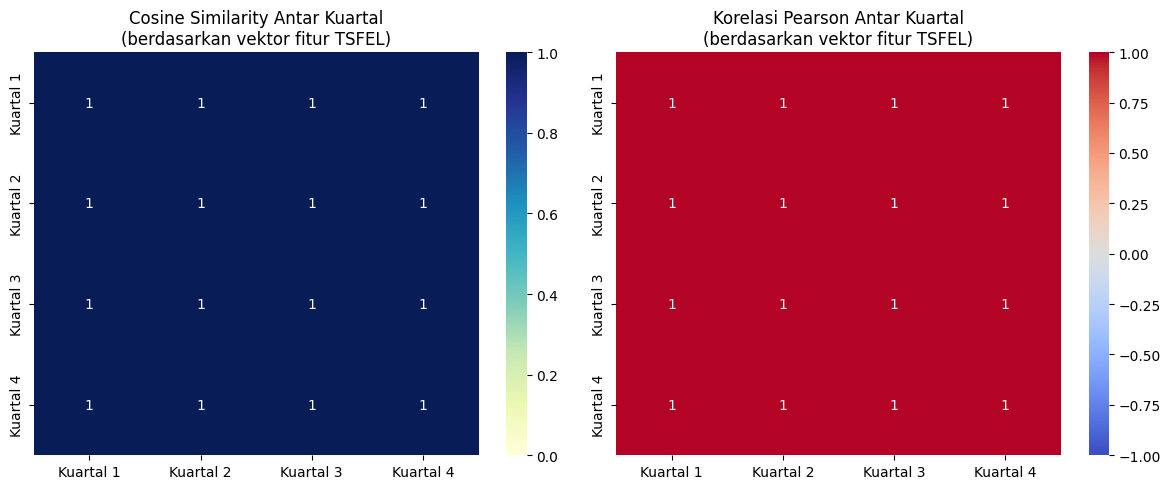

Rata-rata konsentrasi CO per kuartal (mol/m²):
- Kuartal 1: 0.03448
- Kuartal 2: 0.03000
- Kuartal 3: 0.03453
- Kuartal 4: 0.03086


In [ ]:
nilai_tahunan = df_final[POLUTAN].values
kuartal_arrays = np.array_split(nilai_tahunan, 4)
nama_kuartal = [f"Kuartal {i + 1}" for i in range(4)]

daftar_fitur_kuartal = [
    ekstrak_fitur_tsfel(arr, nama)
    for arr, nama in zip(kuartal_arrays, nama_kuartal)
]
df_fitur_kuartal = pd.concat(daftar_fitur_kuartal, axis=0)

kolom_konstan = df_fitur_kuartal.columns[df_fitur_kuartal.std(axis=0) == 0]
df_fitur_kuartal_bersih = df_fitur_kuartal.drop(columns=kolom_konstan)
print(f"Kolom fitur dibuang karena konstan di semua kuartal: {len(kolom_konstan)} kolom")
print(f"Kolom fitur dipakai untuk analisis kemiripan: {df_fitur_kuartal_bersih.shape[1]} kolom\n")

# 1. Cosine similarity antar kuartal berdasarkan vektor fitur TSFEL
sim_matrix = cosine_similarity(df_fitur_kuartal_bersih.values)
df_cos_sim = pd.DataFrame(sim_matrix, index=nama_kuartal, columns=nama_kuartal)

# 2. Korelasi Pearson antar kuartal (dihitung dari vektor fitur yang sama)
df_pearson = df_fitur_kuartal_bersih.T.corr(method="pearson")
df_pearson.index = nama_kuartal
df_pearson.columns = nama_kuartal

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(df_cos_sim, annot=True, cmap="YlGnBu", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Cosine Similarity Antar Kuartal\n(berdasarkan vektor fitur TSFEL)")

sns.heatmap(df_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Pearson Antar Kuartal\n(berdasarkan vektor fitur TSFEL)")

plt.tight_layout()
plt.show()

print("Rata-rata konsentrasi CO per kuartal (mol/m²):")
for nama, arr in zip(nama_kuartal, kuartal_arrays):
    print(f"- {nama}: {arr.mean():.5f}")


## Langkah 7 — Dokumentasi Lengkap Fitur TSFEL

Bagian ini merangkum **definisi, cara kerja, cara menghitung, rumus, dan makna** dari fitur-fitur utama yang diekstraksi TSFEL, dikelompokkan menurut 3 domain (Statistik, Temporal, Spektral), mengikuti gaya penjelasan pada slide `Ekstraksi_Fitur_TSFEL.pptx`. Fitur-fitur lain yang tidak dibahas satu per satu di sini (misalnya varian FFT-coefficient per indeks, wavelet, atau histogram) mengikuti prinsip domain yang sama dan bisa dicek langsung dari nama kolomnya di `df_fitur_tahunan`.

> Jika ada bagian yang masih belum dipahami setelah membaca dokumentasi ini, silakan dicatat dan ditanyakan pada pertemuan/minggu depan.

---

### 1. Domain Statistik

#### **Mean**
- **Definisi**: Nilai rata-rata konsentrasi CO selama periode yang diamati (365 hari untuk fitur tahunan, ±91 hari untuk fitur per kuartal).
- **Cara Kerja & Menghitung**: Seluruh nilai CO harian dijumlahkan lalu dibagi jumlah observasi $N$.
- **Rumus**: $\mu = \dfrac{1}{N} \sum_{i=1}^{N} x_i$
- **Makna**: Baseline rata-rata paparan polusi CO di kecamatan tersebut pada periode itu.

#### **Variance**
- **Definisi**: Ukuran penyebaran kuadrat data CO di sekitar nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Menghitung kuadrat selisih tiap data harian terhadap mean, lalu dirata-ratakan.
- **Rumus**: $\sigma^2 = \dfrac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$
- **Makna**: Mengukur stabilitas/fluktuasi konsentrasi polutan harian — makin besar, makin fluktuatif.

#### **Standard Deviation**
- **Definisi**: Akar kuadrat varians, mengukur sebaran data dalam satuan asli (bukan kuadrat).
- **Cara Kerja & Menghitung**: Menarik akar kuadrat dari hasil perhitungan varians.
- **Rumus**: $\sigma = \sqrt{\sigma^2}$
- **Makna**: Seberapa jauh kondisi CO harian menyimpang dari rata-rata periode tersebut, dalam satuan yang sama dengan data asli.

#### **Skewness**
- **Definisi**: Ukuran ketidaksimetrisan (kemencengan) distribusi konsentrasi CO.
- **Cara Kerja & Menghitung**: Menghitung momen ketiga terstandardisasi dari data.
- **Rumus**: $\gamma_1 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^3}{\sigma^3}$
- **Makna**: Skewness positif menandakan ada beberapa hari dengan lonjakan polusi ekstrem yang menarik ekor distribusi ke kanan.

#### **Kurtosis**
- **Definisi**: Derajat keruncingan dan ketebalan ekor distribusi data CO.
- **Cara Kerja & Menghitung**: Menghitung momen keempat terstandardisasi.
- **Rumus**: $\beta_2 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^4}{\sigma^4}$
- **Makna**: Kurtosis tinggi berarti variabilitas polusi didominasi lonjakan singkat bernilai ekstrem, bukan fluktuasi merata.

#### **Root Mean Square (RMS)**
- **Definisi**: Akar rata-rata kuadrat dari magnitudo sinyal CO (lihat contoh manual di slide: X=[2,-1,3,-2,4] → RMS ≈ 2.61).
- **Cara Kerja & Menghitung**: Kuadratkan tiap nilai harian → rata-ratakan → tarik akar kuadrat.
- **Rumus**: $x_{rms} = \sqrt{\dfrac{1}{N}\sum_{i=1}^{N} x_i^2}$
- **Makna**: Merepresentasikan besarnya "energi" atau intensitas beban polusi secara keseluruhan pada periode itu.

#### **Interquartile Range (IQR sebagai fitur)**
- **Definisi**: Selisih antara kuartil atas $Q_3$ dan kuartil bawah $Q_1$ dari data pada window tersebut.
- **Cara Kerja & Menghitung**: Urutkan data, tentukan posisi persentil ke-75 dan ke-25, hitung selisihnya.
- **Rumus**: $IQR = Q_3 - Q_1$
- **Makna**: Sebaran 50% data tengah, tidak terpengaruh nilai ekstrem — pelengkap dari IQR yang sudah dipakai di Langkah 3 untuk deteksi outlier.

#### **Absolute Energy**
- **Definisi**: Akumulasi total kuadrat nilai sinyal CO.
- **Cara Kerja & Menghitung**: Jumlahkan kuadrat seluruh nilai CO harian pada window tersebut.
- **Rumus**: $E = \sum_{i=1}^{N} x_i^2$
- **Makna**: Total beban kuantitatif akumulasi CO yang "diterima" lingkungan pada periode tersebut.

#### **Mean Absolute Deviation (MAD, versi statistik)**
- **Definisi**: Rata-rata jarak mutlak setiap data harian terhadap nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Jumlahkan nilai absolut selisih tiap titik terhadap mean, bagi $N$.
- **Rumus**: $MAD = \dfrac{1}{N}\sum_{i=1}^{N} |x_i - \mu|$
- **Makna**: Mengukur variabilitas harian dengan cara yang lebih tahan terhadap outlier dibanding standar deviasi.

#### **ECDF / Quantiles (0.1, 0.25, 0.5, 0.75, 0.9)**
- **Definisi**: Nilai ambang pada persentil tertentu dari fungsi distribusi kumulatif empiris data CO.
- **Cara Kerja & Menghitung**: Urutkan data dari terkecil ke terbesar, ambil titik potong pada persentil terkait.
- **Rumus**: $P(X \le x_p) = p$
- **Makna**: Quantile 0.5 (median) menunjukkan titik tengah polusi; quantile 0.9 menggambarkan kondisi 10% hari terburuk pada periode tersebut.

---

### 2. Domain Temporal

#### **Autocorrelation**
- **Definisi**: Korelasi sinyal CO terhadap dirinya sendiri dengan jeda waktu $k$ hari.
- **Cara Kerja & Menghitung**: Membandingkan deret $x_t$ dengan deret yang sama namun digeser $k$ hari ($x_{t+k}$).
- **Rumus**: $R(k) = \dfrac{\sum_{t=1}^{N-k}(x_t-\mu)(x_{t+k}-\mu)}{\sum_{t=1}^{N}(x_t-\mu)^2}$
- **Makna**: Mengukur "memori" udara — autokorelasi lag-1 tinggi berarti polusi hari ini sangat mirip dengan hari kemarin.

#### **Zero Crossing Rate (ZCR)**
- **Definisi**: Frekuensi deret waktu memotong (melewati) nilai rata-ratanya (lihat contoh manual di slide: X=[2,-1,3,-2,4] → 4 transisi).
- **Cara Kerja & Menghitung**: Menghitung berapa kali terjadi perubahan tanda pada $(x_t - \mu)$.
- **Rumus**: $ZCR = \dfrac{1}{N-1}\sum_{t=1}^{N-1} \mathbb{1}\big[(x_t-\mu)(x_{t+1}-\mu) < 0\big]$
- **Makna**: Menggambarkan seberapa sering kondisi udara berpindah dari "di bawah rata-rata" ke "di atas rata-rata" atau sebaliknya.

#### **Mean Absolute Differences**
- **Definisi**: Rata-rata perubahan mutlak CO dari satu hari ke hari berikutnya (lihat contoh manual di slide: X=[2,-1,3,-2,4] → MAD = 4.5).
- **Cara Kerja & Menghitung**: Jumlahkan nilai mutlak selisih antar hari berturut-turut, bagi $N-1$.
- **Rumus**: $\dfrac{1}{N-1}\sum_{t=1}^{N-1} |x_{t+1}-x_t|$
- **Makna**: Menunjukkan seberapa cepat/volatil perubahan kondisi udara harian.

#### **Peak Detection**
- **Definisi**: Jumlah puncak lokal (local maxima) pada deret waktu.
- **Cara Kerja & Menghitung**: Menghitung titik di mana $x_t > x_{t-1}$ dan $x_t > x_{t+1}$, opsional melebihi ambang tertentu.
- **Makna**: Menunjukkan seberapa sering terjadi lonjakan singkat pencemaran CO pada periode tersebut.

#### **Temporal Centroid**
- **Definisi**: "Pusat gravitasi waktu" dari sinyal CO — kapan (di titik waktu mana) sebagian besar "bobot" konsentrasi terkumpul.
- **Cara Kerja & Menghitung**: Rata-rata tertimbang indeks waktu, dengan bobot = nilai CO itu sendiri.
- **Rumus**: $Centroid = \dfrac{\sum_{t=1}^{N} t \cdot x_t}{\sum_{t=1}^{N} x_t}$
- **Makna**: Menunjukkan pada periode mana (awal/akhir window) konsentrasi CO cenderung lebih terkonsentrasi.

#### **Slope (Linear Trend)**
- **Definisi**: Kemiringan garis lurus hasil regresi linear terhadap deret waktu.
- **Cara Kerja & Menghitung**: Fit garis $y = m \cdot t + c$ dengan metode kuadrat terkecil (least squares).
- **Rumus**: $m = \dfrac{N\sum(t \cdot x_t) - \sum t \sum x_t}{N \sum t^2 - (\sum t)^2}$
- **Makna**: Kemiringan positif ($m>0$) menunjukkan CO cenderung meningkat sepanjang periode tersebut; negatif berarti menurun.

#### **Area Under Curve (AUC)**
- **Definisi**: Luas daerah di bawah kurva grafik deret waktu CO.
- **Cara Kerja & Menghitung**: Aturan integrasi trapesium pada deret waktu.
- **Rumus**: $AUC = \sum_{t=1}^{N-1} \dfrac{x_t + x_{t+1}}{2}$
- **Makna**: Total paparan akumulatif CO sepanjang periode tersebut.

---

### 3. Domain Spektral (berbasis FFT)

Semua fitur di domain ini bekerja dengan cara yang sama: sinyal CO 365 harian pertama-tama ditransformasikan ke domain frekuensi memakai **Fast Fourier Transform (FFT)** — memecah gelombang naik-turun konsentrasi CO yang kompleks menjadi kumpulan gelombang sinus/kosinus sederhana dengan frekuensi & magnitudo berbeda (lihat konsep DFT di slide 14–19).

#### **Spectral Centroid**
- **Definisi**: "Pusat gravitasi" frekuensi dari spektrum sinyal (lihat contoh manual di slide: Magnitudo=[3,1,3,1] → Centroid = 1.25).
- **Cara Kerja & Menghitung**: Transformasi FFT, lalu rata-rata frekuensi tertimbang oleh daya spektralnya.
- **Rumus**: $f_c = \dfrac{\sum f \cdot P(f)}{\sum P(f)}$
- **Makna**: Apakah variasi CO didominasi fluktuasi jangka panjang (frekuensi rendah/musiman) atau perubahan harian yang cepat (frekuensi tinggi).

#### **Spectral Spread**
- **Definisi**: Standar deviasi dari spektrum frekuensi di sekitar spectral centroid (lihat contoh manual di slide: SC=1.25 → Spread ≈ 1.089).
- **Cara Kerja & Menghitung**: Momen kedua spektral terhadap pusat spektrum (mirip varians, tapi di domain frekuensi).
- **Rumus**: $Spread = \sqrt{\dfrac{\sum (f-f_c)^2 P(f)}{\sum P(f)}}$
- **Makna**: Menunjukkan seberapa lebar rentang frekuensi yang berkontribusi pada dinamika emisi CO.

#### **Fundamental Frequency**
- **Definisi**: Frekuensi dasar dengan magnitudo spektral tertinggi.
- **Cara Kerja & Menghitung**: Mengidentifikasi puncak tertinggi pada spektrum daya hasil FFT.
- **Rumus**: $f_0 = \arg\max_f P(f)$
- **Makna**: Mengungkap siklus alami polusi CO yang paling dominan (misalnya siklus mingguan akibat lalu lintas, atau siklus musiman).

#### **Spectral Entropy**
- **Definisi**: Ukuran keacakan distribusi daya frekuensi sinyal CO, mengadopsi entropi Shannon (lihat contoh manual di slide: p=[0.45,0.05,0.45,0.05] → entropi ≈ 1.469 bit).
- **Cara Kerja & Menghitung**: Normalisasi spektrum daya menjadi distribusi probabilitas $p(f)$, lalu hitung entropi Shannon-nya.
- **Rumus**: $H = -\sum p(f)\log_2 p(f)$, dengan $p(f) = \dfrac{P(f)}{\sum P(f)}$
- **Makna**: Entropi tinggi → pola variasi CO kompleks/acak; entropi rendah → ada pola periodik/musiman yang cukup teratur.


## Ringkasan & Catatan Penutup

- Fokus notebook: **4 polutan utama (CO, NO2, SO2, CH4)**, **1 kecamatan (Sokobanah)**.
- Missing values ditangani dengan **interpolasi waktu + ffill/bfill** untuk setiap polutan.
- Outlier dideteksi dengan **IQR** lalu diperbaiki dengan **Winsorization/capping** (bukan dibuang), sehingga jumlah hari tetap 365.
- Fitur diekstraksi dengan **TSFEL (semua domain: statistik, temporal, spektral)** untuk 365 hari penuh pada setiap polutan, dengan kolom bernama `[nama_fitur] (fX)`.
- Hasil akhir berupa tabel fitur lengkap 68 fitur x 4 polutan, dilengkapi rata-rata konsentrasi tiap polutan dan file Excel hasil ekspor.
- Analisis **kemiripan antar kuartal** pada bagian terakhir difokuskan pada **CO** sebagai contoh pola temporal, namun proses ekstraksi fitur tetap dipakai untuk seluruh polutan.
- Dokumentasi definisi/cara kerja/rumus/makna setiap fitur TSFEL ada di Langkah 7.

**Jika ada bagian dari alur ini atau makna suatu fitur yang belum dipahami, catat pertanyaannya dan bisa ditanyakan pada pertemuan minggu depan.**
